<a href="https://colab.research.google.com/github/njokinjuguna/Machine-learning-Models/blob/main/GPU_bench_marking_with_image_classification_%7C_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)

#version information


2.19.0


In [ ]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
tf.test.is_built_with_cuda()

True

In [ ]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.cifar10.load_data()

In [ ]:
X_train.shape


(50000, 32, 32, 3)

In [ ]:
def plot_sample(index):
  plt.figure(figsize=(10,1))
  plt.imshow(X_train[index])

In [ ]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

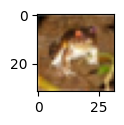

In [ ]:
plot_sample(0)

In [ ]:
y_train.shape

(50000, 1)

preprocessing;scaling

In [ ]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [ ]:
X_train_scaled.shape

(50000, 32, 32, 3)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

one hot encoding

In [ ]:
y_train_categorical=keras.utils.to_categorical(y_train,num_classes=10)
y_train_categorical[:5]


array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
y_test_categorical=keras.utils.to_categorical(y_test,num_classes=10)
y_test_categorical[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

Model Building

In [ ]:
model = keras.Sequential([
      keras.Input(shape=(32,32,3)),
      keras.layers.Flatten(),
      keras.layers.Dense(3000,activation='relu'),
      keras.layers.Dense(1000,activation='relu'),
      keras.layers.Dense(10,activation='sigmoid')
  ])

model.compile(optimizer='SGD',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
model.fit(X_train_scaled, y_train_categorical, epochs=10, validation_split=0.2)


In [ ]:
#model prediction
classes[np.argmax(model.predict(X_test_scaled)[9])]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


'automobile'

In [ ]:
classes[y_test[9][0]]

'automobile'

In [ ]:
#model evaluation
loss, accuracy = model.evaluate(X_test_scaled,y_test_categorical)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5491 - loss: 1.6533
Test Loss: 1.6552, Test Accuracy: 0.5494


CPU


In [ ]:
def get_model():
    model = keras.Sequential([
            keras.layers.Flatten(input_shape=(32,32,3)),
            keras.layers.Dense(3000, activation='relu'),
            keras.layers.Dense(1000, activation='relu'),
            keras.layers.Dense(10, activation='sigmoid')
        ])

    model.compile(optimizer='SGD',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
%timeit -n1 -r1
with tf.device('/CPU:0'):
  CPU_model=get_model()
  CPU_model.fit(X_train_scaled,y_train_categorical,epochs=1, verbose=0)

GPU

In [ ]:
%timeit -n1 -r1
with tf.device('/GPU:0'):
  GPU_model=get_model()
  GPU_model.fit(X_train_scaled,y_train_categorical,epochs=1, verbose=0)

**CPU** TAKES **109 seconds** to run i epoch while
**GPU** takes** 6 seconds** to run 1 epoch **bold text**